<a href="https://colab.research.google.com/github/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/blob/main/notebooks/05_Engineering_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Engineering Analysis

## Purpose

This notebook uses the optimised Support Vector Regression (SVR) model selected in the previous analysis to investigate the engineering behaviour of airfoil self noise.

The analysis examines how predicted sound pressure level responds to changes in the five input variables:

- Frequency (Hz)
- Angle of attack (°)
- Chord length (m)
- Free-stream velocity (m/s)
- Displacement thickness (m)

Sensitivity analysis is performed within the range of the experimental dataset to investigate the relationships learned by the model. Prediction errors are also examined to identify operating conditions where the model performs less
reliably.

The aim is to interpret the computational results in an engineering context rather than considering predictive accuracy alone.

# **Importing Libraries and Loading Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Define column names because the original dataset has no header row
column_names = [
    "frequency",
    "angle_of_attack",
    "chord_length",
    "free_stream_velocity",
    "displacement_thickness",
    "sound_pressure_level"
]

# Load the experimental airfoil dataset from the project GitHub repository
data_url = "https://raw.githubusercontent.com/lkoc0002/MMA3001-Project-Airfoil-Noise-Prediction/refs/heads/main/data/airfoil_self_noise.dat"

df = pd.read_csv(
    data_url,
    sep="\t",
    names=column_names
)

# Separate the engineering inputs from the measured output
X = df[
    [
        "frequency",
        "angle_of_attack",
        "chord_length",
        "free_stream_velocity",
        "displacement_thickness"
    ]
]

y = df["sound_pressure_level"]

# Reproduce the same train-test split used throughout the project
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# **Forming the optimised SVR model**

## Selected Model

The model comparison identified the optimised SVR as the strongest predictive
model among the methods evaluated. The selected hyperparameters were obtained
using five-fold cross-validation on the training data:

- C = 100
- epsilon = 0.5
- gamma = 1

The model is recreated using these parameters for engineering sensitivity and
error analysis.

In [5]:
# Recreate the final SVR model using the hyperparameters selected previously
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=100,
        epsilon=0.5,
        gamma=1
    ))
])

final_model.fit(X_train, y_train)

# Generate predictions for the withheld test observations
y_test_pred = final_model.predict(X_test)

## **Sensitivity Analysis**

A sensitivity analysis done on one variable at a time is used to examine how the selected model responds to changes in each engineering input.

For each analysis, one input variable is varied across its observed dataset
range while the remaining variables are held at representative median values.

This approach provides an interpretable view of the relationships learned by
the model. However, the results represent model sensitivity rather than direct causal relationships, since combinations generated during the analysis may not correspond exactly to experimental operating conditions in the original
dataset.

In [6]:
def sensitivity_prediction(model, data, variable, points=100):
    """
    Predict sound pressure level while varying one engineering input.

    Parameters
    ----------
    model : regression model
        The fitted regression model used to predict sound pressure level.
    data : pandas DataFrame
        The input dataset containing the engineering variables.
    variable : str
        The name of the input variable to vary.
    points : int, optional
        The number of values evaluated across the observed variable range.
        The default is 100.

    Returns
    -------
    variable_values : numpy.ndarray
        Values of the selected engineering variable used for prediction.
    predictions : numpy.ndarray
        Predicted sound pressure levels corresponding to each variable value.
    """

    # Use median operating conditions as the reference point
    reference = data.median()

    # Vary the selected variable only within its observed dataset range
    variable_values = np.linspace(
        data[variable].min(),
        data[variable].max(),
        points
    )

    sensitivity_data = pd.DataFrame(
        [reference.values] * points,
        columns=data.columns
    )

    sensitivity_data[variable] = variable_values

    predictions = model.predict(sensitivity_data)

    return variable_values, predictions

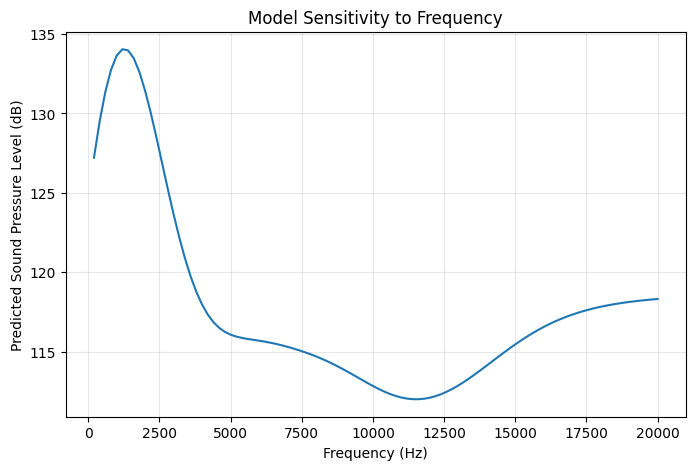

In [7]:
# Frequency sensitivity
frequency_values, frequency_predictions = sensitivity_prediction(
    final_model,
    X_train,
    "frequency"
)

plt.figure(figsize=(8, 5))

plt.plot(
    frequency_values,
    frequency_predictions
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Model Sensitivity to Frequency")
plt.grid(alpha=0.3)

plt.show()

### Frequency Sensitivity

The model shows a strongly nonlinear relationship between frequency and
predicted sound pressure level. At the reference operating conditions, predicted SPL initially increases and reaches a peak at approximately 1–2 kHz before decreasing substantially as frequency increases. The predicted SPL reaches a minimum at approximately 11–12 kHz before increasing gradually at higher frequencies.

This nonlinear response is consistent with the earlier finding that frequency cannot be represented adequately by a simple linear relationship with sound
pressure level. The sensitivity curve represents the behaviour learned by the SVR at the selected reference conditions and should not be interpreted as a universal frequency response for all operating conditions.

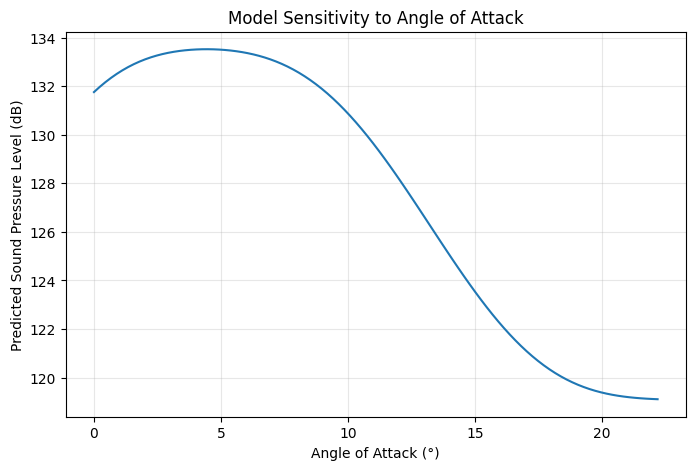

In [8]:
# Angle of attack sensitivity
angle_values, angle_predictions = sensitivity_prediction(
    final_model,
    X_train,
    "angle_of_attack"
)

plt.figure(figsize=(8, 5))

plt.plot(
    angle_values,
    angle_predictions
)

plt.xlabel("Angle of Attack (°)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Model Sensitivity to Angle of Attack")
plt.grid(alpha=0.3)

plt.show()

### Angle of Attack Sensitivity

At the reference operating conditions, predicted sound pressure level increases
slightly between 0° and approximately 5° angle of attack. Beyond this region, the predicted SPL decreases, with a more substantial reduction occurring above approximately 10°.

The response is clearly nonlinear and indicates that the influence of angle of attack predicted by the model depends on the operating region. This result should be interpreted as model sensitivity at the selected reference conditions rather than evidence that increasing angle of attack will always reduce airfoil
noise.

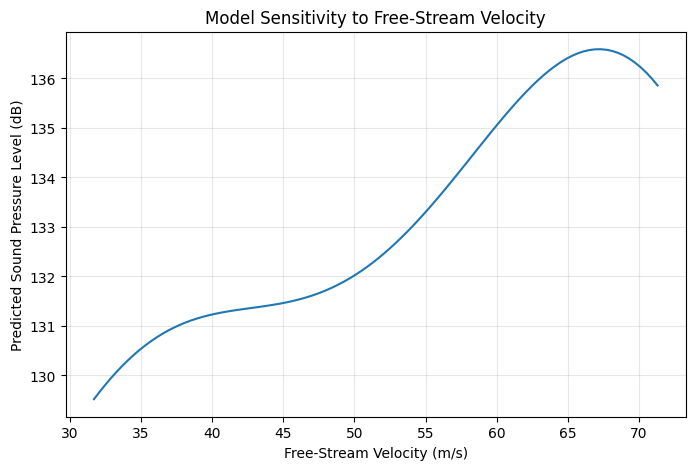

In [9]:
# Free stream velocity sensitivity
velocity_values, velocity_predictions = sensitivity_prediction(
    final_model,
    X_train,
    "free_stream_velocity"
)

plt.figure(figsize=(8, 5))

plt.plot(
    velocity_values,
    velocity_predictions
)

plt.xlabel("Free-Stream Velocity (m/s)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Model Sensitivity to Free-Stream Velocity")
plt.grid(alpha=0.3)

plt.show()

### Free Stream Velocity Sensitivity

The model generally predicts increasing sound pressure level as free stream velocity increases. Predicted SPL rises from approximately 129.5 dB at the
lowest velocity to above 136 dB at the higher velocities, before showing a small reduction near the upper end of the observed range.

Compared with some of the other variables, the velocity response is relatively smooth. The results indicate that free stream velocity has an important influence on the predicted noise level under the reference operating
conditions.

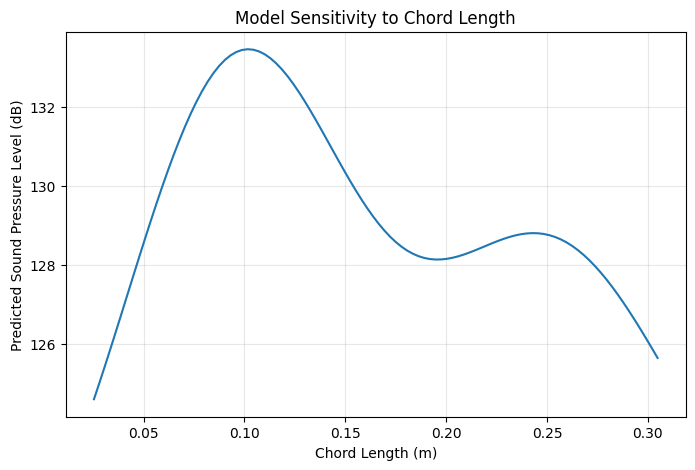

In [10]:
# Chord length sensitivity
chord_values, chord_predictions = sensitivity_prediction(
    final_model,
    X_train,
    "chord_length"
)

plt.figure(figsize=(8, 5))

plt.plot(
    chord_values,
    chord_predictions
)

plt.xlabel("Chord Length (m)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Model Sensitivity to Chord Length")
plt.grid(alpha=0.3)

plt.show()

### Chord Length Sensitivity

The relationship between chord length and predicted sound pressure level is
nonlinear. Predicted SPL initially increases with chord length and reaches a local maximum near 0.10 m. It then decreases before showing a smaller increase around 0.24–0.25 m, followed by another decrease toward the largest chord length.

The non monotonic response suggests that chord length interacts with the other operating variables rather than having a simple independent relationship with sound pressure level. Since only a small number of discrete chord lengths are
represented in the experimental dataset, predictions between these values should also be interpreted cautiously.

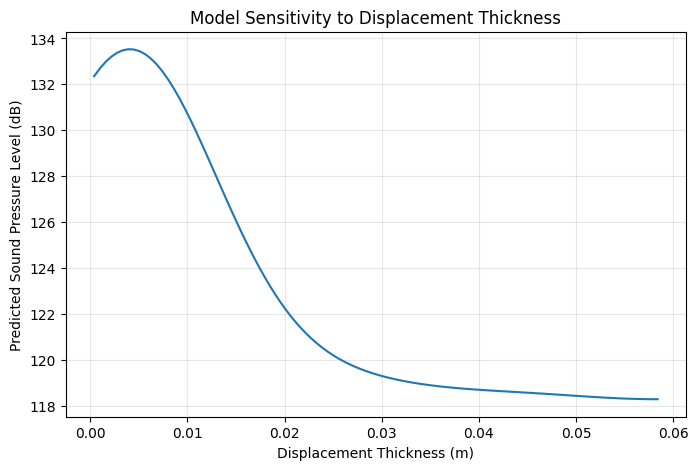

In [11]:
# Displacement thickness sensitivity
thickness_values, thickness_predictions = sensitivity_prediction(
    final_model,
    X_train,
    "displacement_thickness"
)

plt.figure(figsize=(8, 5))

plt.plot(
    thickness_values,
    thickness_predictions
)

plt.xlabel("Displacement Thickness (m)")
plt.ylabel("Predicted Sound Pressure Level (dB)")
plt.title("Model Sensitivity to Displacement Thickness")
plt.grid(alpha=0.3)

plt.show()

### Displacement Thickness Sensitivity

At the reference operating conditions, predicted sound pressure level reaches a small maximum at low displacement thickness before decreasing substantially as
displacement thickness increases. The rate of decrease becomes smaller at
higher displacement thickness values.

This indicates a strong nonlinear relationship between displacement thickness and the model prediction. However, displacement thickness is associated with the aerodynamic operating condition and should not be interpreted as an independent control variable. The sensitivity curve therefore describes the response learned by the SVR while the other model inputs are held fixed.

## **Prediction Error Analysis**

Although the optimised SVR achieved strong overall predictive performance,
individual observations showed larger prediction errors. The absolute
prediction errors are examined to identify operating conditions where the model performs less reliably.

In [15]:
# Create a table containing the test conditions and corresponding predictions
error_analysis = X_test.copy()

error_analysis["measured_SPL"] = y_test.values
error_analysis["predicted_SPL"] = y_test_pred

# Calculate signed and absolute prediction errors
error_analysis["error"] = (
    error_analysis["measured_SPL"]
    - error_analysis["predicted_SPL"]
)

error_analysis["absolute_error"] = np.abs(
    error_analysis["error"]
)

# Display the ten test observations with the largest prediction errors
largest_errors = error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

largest_errors

,frequency,angle_of_attack,chord_length,free_stream_velocity,displacement_thickness,measured_SPL,predicted_SPL,error,absolute_error
1187,1000,17.4,0.0254,39.6,0.017221,138.274,124.013162,14.260838,14.260838
29,200,0.0,0.3048,39.6,0.003101,118.129,126.175223,-8.046223,8.046223
49,250,0.0,0.3048,31.7,0.003313,118.595,125.862541,-7.267541,7.267541
30,250,0.0,0.3048,39.6,0.003101,119.319,126.427104,-7.108104,7.108104
316,400,4.0,0.2286,55.5,0.004286,123.274,129.823835,-6.549835,6.549835
939,630,19.7,0.0508,71.3,0.034118,128.365,122.261187,6.103813,6.103813
1172,1250,17.4,0.0254,55.5,0.016571,129.301,123.218905,6.082095,6.082095
1414,630,12.3,0.1016,71.3,0.033779,135.368,129.817552,5.550448,5.550448
970,16000,0.0,0.0254,71.3,0.000401,130.477,125.038580,5.438420,5.438420
619,1250,7.2,0.1524,39.6,0.009092,122.428,127.533188,-5.105188,5.105188


### **Largest Prediction Errors**

The largest individual prediction error occurred for an observation at
1000 Hz, 17.4° angle of attack, 0.0254 m chord length and 39.6 m/s
free-stream velocity. The measured sound pressure level was approximately
138.27 dB, while the model predicted approximately 124.01 dB, corresponding
to an underprediction of approximately 14.26 dB.

Other large errors occurred across several different combinations of frequency, geometry and operating conditions. This suggests that prediction difficulty is not associated with a single input variable alone.

The presence of these larger errors demonstrates an important limitation of using aggregate performance metrics such as RMSE and R². Although the model provides strong overall predictive performance, individual operating conditions can still produce substantially larger errors.

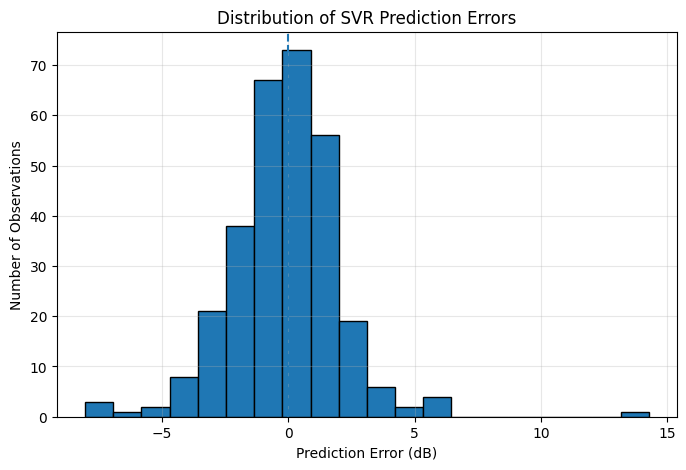

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    error_analysis["error"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Prediction Error (dB)")
plt.ylabel("Number of Observations")
plt.title("Distribution of SVR Prediction Errors")
plt.grid(alpha=0.3)

plt.show()

## **Error Distribution**

The distribution of prediction errors is concentrated around zero, indicating that the model does not show a large systematic tendency to consistently overpredict or underpredict sound pressure level across the test dataset.

Most prediction errors are relatively small, although several larger errors
occur in both directions. One observation produced a substantially larger positive error than the remainder of the test data, showing that strong overall performance metrics do not guarantee accurate prediction for every operating
condition.

## **Model Applicability and Limitations**

The selected SVR model was trained using experimental observations contained within the Airfoil Self-Noise dataset. Its predictions are therefore supported only within the range and combinations of operating conditions represented by
the available data.

The model should not be assumed to provide reliable predictions outside the observed ranges of frequency, angle of attack, chord length, free stream velocity or displacement thickness. SVR is a data driven model and does not directly enforce the physical equations governing aerodynamic noise.

The sensitivity analysis also has limitations. Holding four variables fixed while varying the fifth can generate combinations that are poorly represented, or potentially absent, in the original experimental
dataset. The sensitivity curves should therefore be interpreted as model responses under controlled reference conditions rather than direct causal relationships.

Although the model achieved strong overall test performance, the error analysis identified individual observations with larger prediction errors. Thus, the model is better for estimating general trends and sound pressure levels within the represented experimental domain than for providing high accuracy for every individual operating condition.

## **Findings**

Engineering analysis of the optimised SVR showed that the relationship between the airfoil operating variables and predicted sound pressure level is strongly
nonlinear.

Frequency produced a clear nonlinear response, while free stream velocity generally showed increasing predicted sound pressure level with increasing velocity. Angle of attack, chord length and displacement thickness also produced nonlinear responses, demonstrating that their influence cannot be represented adequately by simple independent linear relationships.

These sensitivity results help explain why the nonlinear models  outperformed the Linear Regression baseline during model comparison. However, the sensitivity curves represent the behaviour learned by the SVR under fixed conditions and should not be interpreted as independent causal relationships.

Prediction errors were generally concentrated around zero, supporting the strong overall test performance of the optimised SVR. Nevertheless, several larger errors were identified, including a maximum observed absolute error of
approximately 14.26 dB. This demonstrates that strong performance does not guarantee accurate prediction for every operating condition.

Overall, the optimised SVR provides a useful model for predicting and investigating airfoil sound pressure level within the experimental domain represented by the dataset. Its predictions should be interpreted alongside the limitations of the available experimental data and should not be extrapolated beyond the represented operating conditions without further validation.